# Advanced Digital Image Processing Pipeline
**Objects:** Circle · Wrench · Hexagon · Leaf · Washer  
**Pipeline:** Generation → Noise → Restoration → Segmentation → Morphology → Features → Classification

## 1. Setup

In [1]:
%matplotlib inline
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

import os, cv2, numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate

from generate_images import generate_all, GENERATORS
from pipeline.noise import apply_noise, DEFAULT_NOISE_CONFIG
from pipeline.restoration import apply_all_spatial_filters
from pipeline.frequency_filters import apply_all_frequency_filters, apply_fft_filter, notch_reject
from pipeline.edge_detection import sobel_edges, laplacian_edges
from pipeline.comparator import compute_mse, compute_psnr, compute_difference_map, evaluate_all_filters, generate_comparison_figure
from pipeline.segmentation import evaluate_segmentation, select_best_segmentation
from pipeline.morphology import evaluate_morphology, boundary_extraction
from pipeline.features import extract_features, features_to_table, features_to_vector, save_features_csv
from pipeline.classification import *

# Force inline backend (override Agg from pipeline modules)
matplotlib.use('module://matplotlib_inline.backend_inline')
plt.switch_backend('module://matplotlib_inline.backend_inline')

for d in ['output/figures','output/tables','output/pca']:
    os.makedirs(d, exist_ok=True)
print("Ready.")

Ready.


## 2. Generate Images

  [+] circle     -> images\raw\circle.png
  [+] wrench     -> images\raw\wrench.png
  [+] hexagon    -> images\raw\hexagon.png
  [+] leaf       -> images\raw\leaf.png
  [+] washer     -> images\raw\washer.png

Generated 5 images + masks.


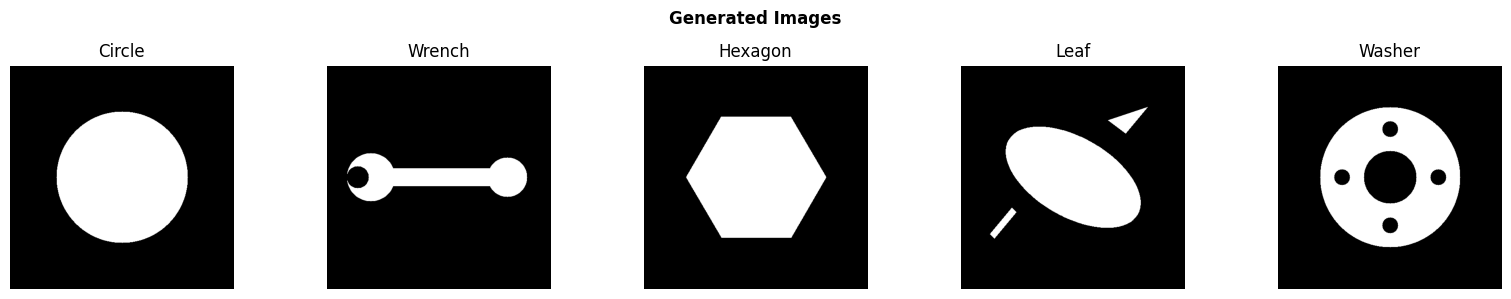

In [2]:
image_paths = generate_all()
OBJ_NAMES = list(GENERATORS.keys())

images, gt_masks = {}, {}
for name in OBJ_NAMES:
    images[name] = cv2.imread(image_paths[name]["image"], cv2.IMREAD_GRAYSCALE)
    gt_masks[name] = cv2.imread(image_paths[name]["mask"], cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 5, figsize=(16, 3))
for ax, n in zip(axes, OBJ_NAMES):
    ax.imshow(images[n], cmap='gray'); ax.set_title(n.capitalize()); ax.axis('off')
plt.suptitle("Generated Images", fontweight='bold'); plt.tight_layout(); plt.show()

## 3. Noise Injection

  circle     <- salt_pepper
  wrench     <- gaussian
  hexagon    <- periodic
  leaf       <- gamma
  washer     <- uniform


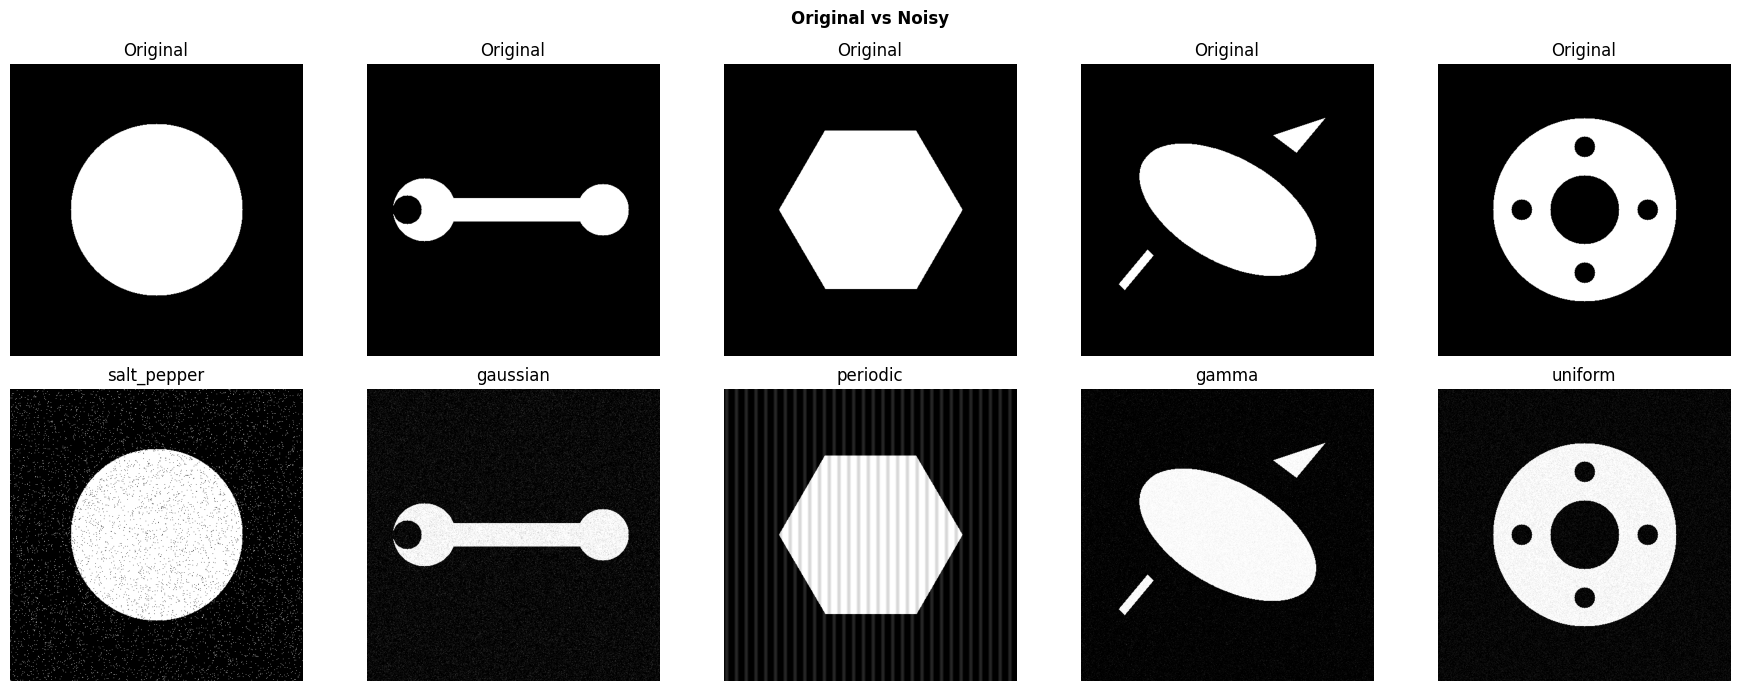

In [3]:
noisy = {}
for n in OBJ_NAMES:
    cfg = DEFAULT_NOISE_CONFIG[n]
    noisy[n] = apply_noise(images[n], cfg["type"], **cfg["params"])
    print(f"  {n:10s} <- {cfg['type']}")

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for i, n in enumerate(OBJ_NAMES):
    axes[0,i].imshow(images[n], cmap='gray'); axes[0,i].set_title("Original"); axes[0,i].axis('off')
    axes[1,i].imshow(noisy[n], cmap='gray'); axes[1,i].set_title(DEFAULT_NOISE_CONFIG[n]['type']); axes[1,i].axis('off')
plt.suptitle("Original vs Noisy", fontweight='bold'); plt.tight_layout(); plt.show()

## 4. Process All Images
Apply filters → evaluate → segment → morphology → extract features

In [4]:
results = {}

for n in OBJ_NAMES:
    print(f"\n{'='*50}\nProcessing: {n.upper()}\n{'='*50}")
    orig = images[n]
    noise_cfg = DEFAULT_NOISE_CONFIG[n]
    r = {}

    # Spatial + frequency filters
    spatial = apply_all_spatial_filters(noisy[n])
    freq = apply_all_frequency_filters(noisy[n])
    if noise_cfg["type"] == "periodic":
        f = noise_cfg["params"].get("frequency", 30)
        for bw in [5, 10, 15]:
            mask = notch_reject(noisy[n].shape, center_freq=f, bandwidth=bw)
            freq[f"Notch BW={bw}"] = apply_fft_filter(noisy[n], mask)

    all_filters = {**spatial, **freq}

    # Enhancement on best spatial
    best_sp, best_p = None, -1
    for fn, fi in spatial.items():
        p = compute_psnr(orig, fi)
        if p > best_p: best_p = p; best_sp = fn
    if best_sp:
        all_filters[f"{best_sp}+HistEq"] = cv2.equalizeHist(spatial[best_sp])
        cl = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        all_filters[f"{best_sp}+CLAHE"] = cl.apply(spatial[best_sp])

    # Best filter (PSNR + segmentation IoU)
    evtbl = evaluate_all_filters(orig, noisy[n], all_filters)
    top3 = [e for e in evtbl[:4] if e["filter"] != "Noisy (no filter)"][:3]
    best_iou, best_fn, best_img = -1, evtbl[0]["filter"], noisy[n]
    for entry in top3:
        fimg = all_filters.get(entry["filter"], noisy[n])
        seg = evaluate_segmentation(fimg, gt_masks[n])
        bm = select_best_segmentation(seg)
        iou = seg[bm]["iou"] or 0
        if iou > best_iou: best_iou = iou; best_fn = entry["filter"]; best_img = fimg

    r["filter"] = best_fn
    r["restored"] = best_img
    r["mse"] = compute_mse(orig, best_img)
    r["psnr"] = compute_psnr(orig, best_img)
    print(f"  Best filter: {best_fn} (PSNR={r['psnr']:.2f} dB)")

    # Segmentation
    seg = evaluate_segmentation(best_img, gt_masks[n])
    r["seg_method"] = select_best_segmentation(seg)
    r["seg_mask"] = seg[r["seg_method"]]["mask"]
    r["seg_iou"] = seg[r["seg_method"]]["iou"]
    print(f"  Segmentation: {r['seg_method']} (IoU={r['seg_iou']:.4f})")

    # Morphology
    morph = evaluate_morphology(r["seg_mask"], gt_masks[n])
    r["morph"] = morph
    r["morph_mask"] = morph.get("best_mask", r["seg_mask"])
    print(f"  Morphology: {morph.get('best_operation','N/A')} "
          f"({morph.get('best_kernel_shape','')}-{morph.get('best_kernel_size','')}) "
          f"IoU={morph.get('best_iou',0):.4f}")

    # Features
    r["features"] = extract_features(r["morph_mask"])
    r["boundary"] = boundary_extraction(r["morph_mask"])
    r["diff"] = compute_difference_map(orig, best_img)

    # Save comparison figure
    generate_comparison_figure(orig, noisy[n], best_img, r["diff"],
        r["mse"], r["psnr"], n.capitalize(), noise_cfg["type"],
        best_fn, save_path=f"output/figures/{n}_comparison.png")

    results[n] = r

print("\nDone!")


Processing: CIRCLE


  Best filter: Median 3x3 (PSNR=36.40 dB)
  Segmentation: Global (IoU=0.9992)
  Morphology: Closing (ellipse-7) IoU=0.9993



Processing: WRENCH


  Best filter: Median 3x3 (PSNR=30.63 dB)
  Segmentation: Global (IoU=0.9991)
  Morphology: Closing (rect-3) IoU=0.9991



Processing: HEXAGON


...


Processing: LEAF


  Best filter: Median 3x3 (PSNR=37.83 dB)
  Segmentation: Global (IoU=0.9998)
  Morphology: Closing (rect-3) IoU=0.9998



Processing: WASHER


  Best filter: Median 3x3 (PSNR=31.37 dB)
  Segmentation: Global (IoU=0.9996)
  Morphology: Opening (rect-3) IoU=0.9996



Done!


## 5. Comparison Figures

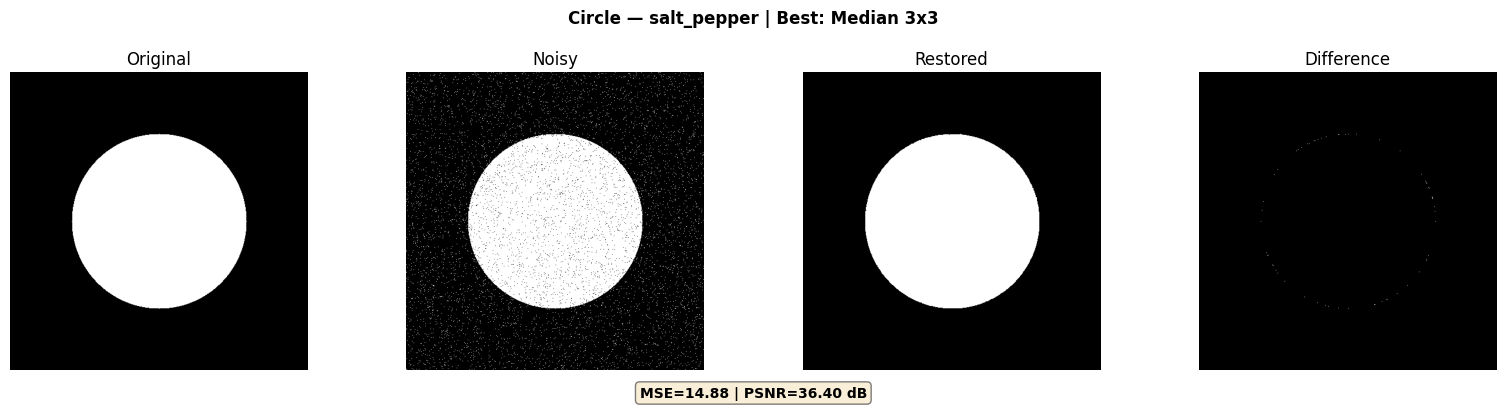

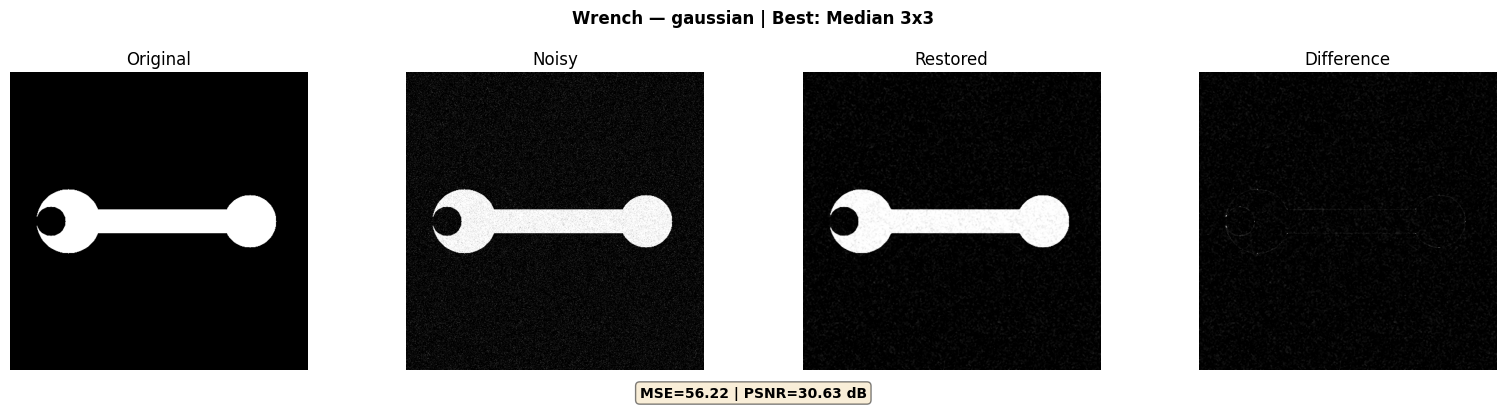

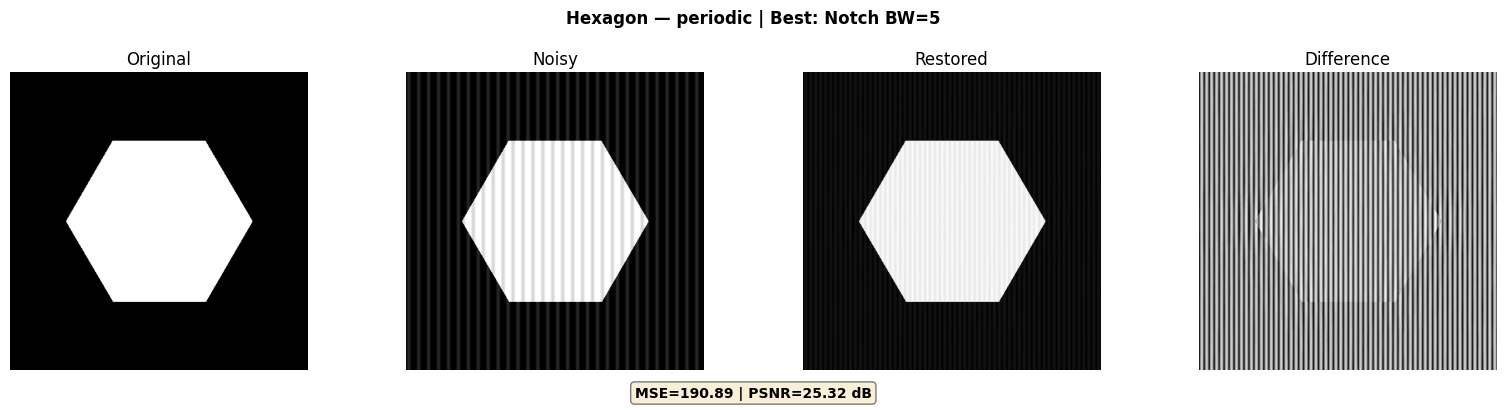

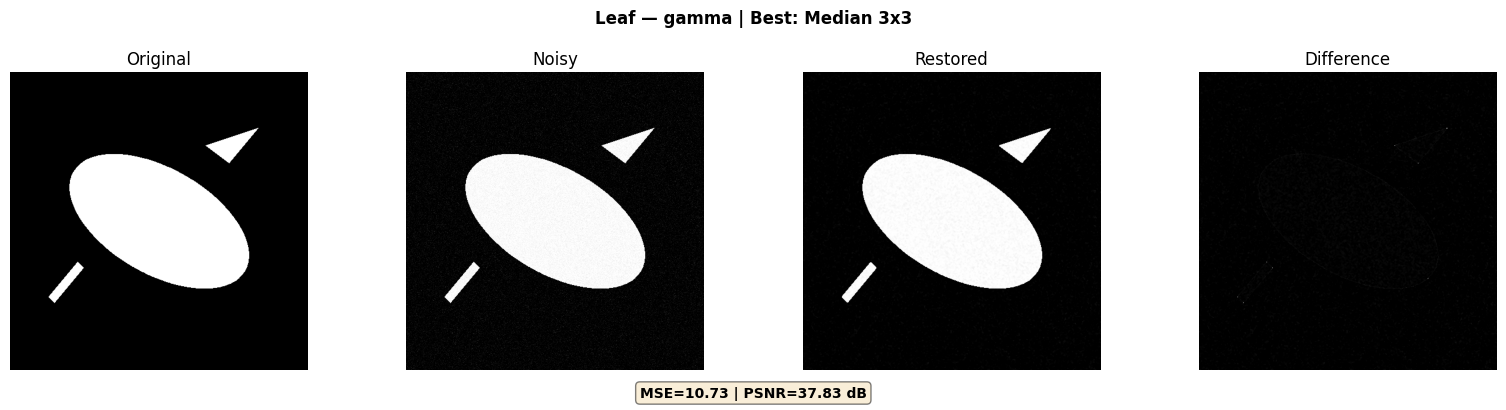

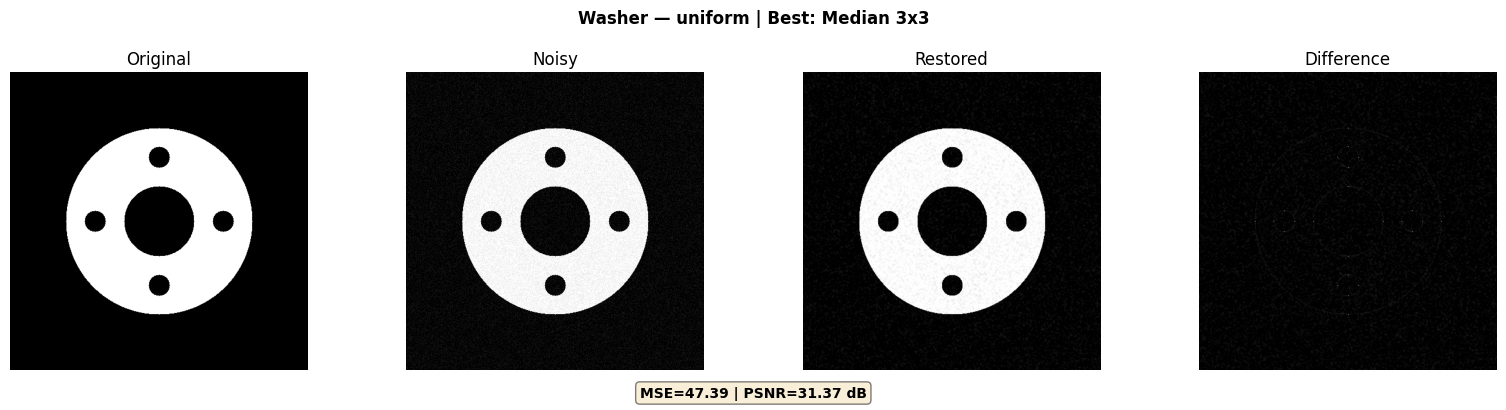

In [5]:
for n in OBJ_NAMES:
    r = results[n]
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(f"{n.capitalize()} — {DEFAULT_NOISE_CONFIG[n]['type']} | Best: {r['filter']}", fontweight='bold')
    for ax, (img, t) in zip(axes, [(images[n],"Original"),(noisy[n],"Noisy"),(r["restored"],"Restored"),(r["diff"],"Difference")]):
        ax.imshow(img, cmap='gray', vmin=0, vmax=255); ax.set_title(t); ax.axis('off')
    fig.text(0.5, 0.01, f"MSE={r['mse']:.2f} | PSNR={r['psnr']:.2f} dB", ha='center', fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    plt.tight_layout(rect=[0,0.04,1,0.95]); plt.show()

## 6. Segmentation & Morphology

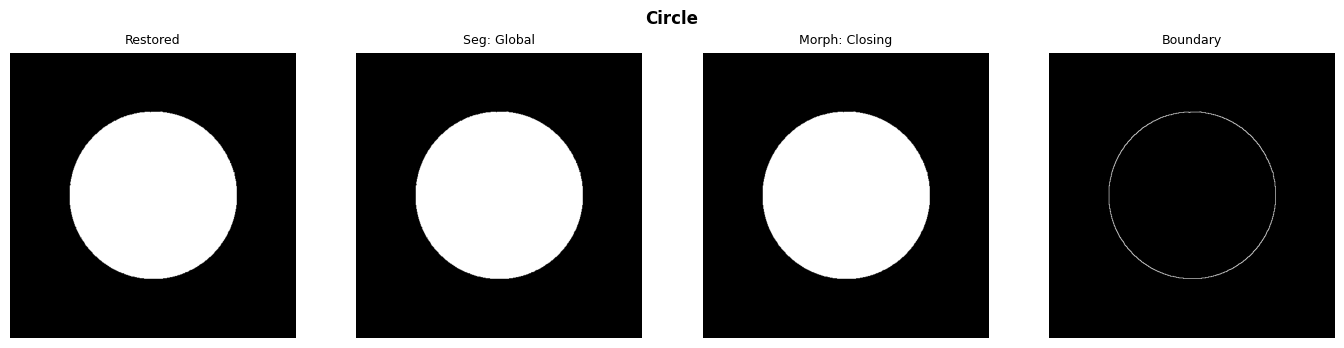

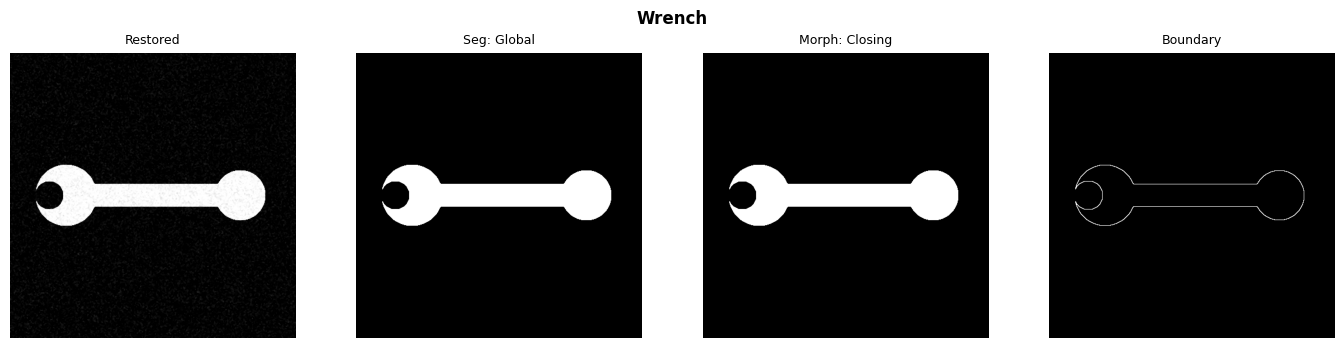

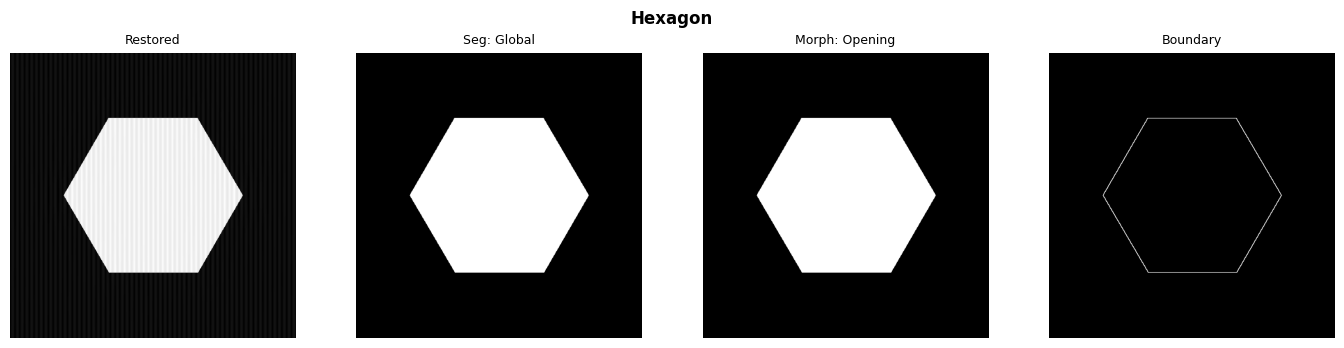

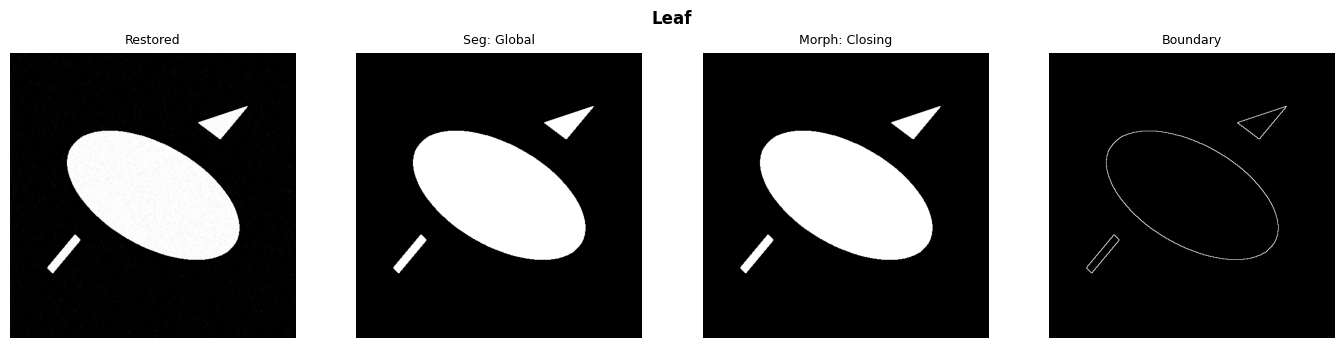

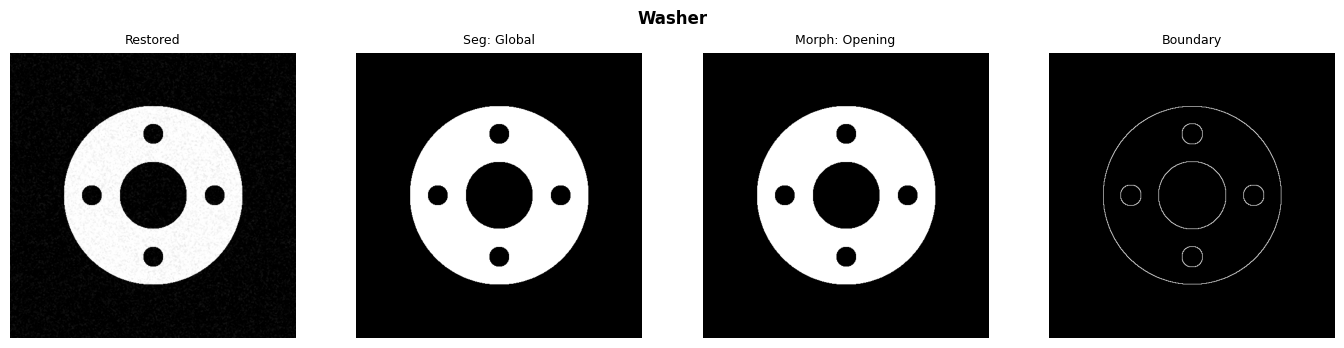

In [6]:
for n in OBJ_NAMES:
    r = results[n]; m = r["morph"]
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    fig.suptitle(f"{n.capitalize()}", fontweight='bold')
    for ax, (img, t) in zip(axes, [(r["restored"],"Restored"), (r["seg_mask"],f"Seg: {r['seg_method']}"),
                                    (r["morph_mask"],f"Morph: {m.get('best_operation','')}"), (r["boundary"],"Boundary")]):
        ax.imshow(img, cmap='gray'); ax.set_title(t, fontsize=9); ax.axis('off')
    plt.tight_layout(); plt.show()

## 7. Feature Extraction

In [7]:
all_feats = {n: r["features"] for n, r in results.items() if r["features"]}
save_features_csv(all_feats, "output/tables/features.csv")
headers, rows = features_to_table(all_feats)
print(tabulate(rows, headers=headers, tablefmt="github", floatfmt=".4f"))

| Object   |       Area |   Perimeter |   Circularity |   Aspect Ratio |   Solidity |   Extent |   Holes |
|----------|------------|-------------|---------------|----------------|------------|----------|---------|
| Circle   | 70259.0000 |    992.9700 |        0.8954 |         0.9967 |     0.9957 |   0.7833 |       0 |
| Wrench   | 22178.0000 |   1127.3500 |        0.2193 |         3.7615 |     0.5751 |   0.4963 |       0 |
| Hexagon  | 66102.0000 |   1003.3800 |        0.8251 |         1.1588 |     0.9961 |   0.7434 |       0 |
| Leaf     | 48042.0000 |    881.5200 |        0.7769 |         1.3377 |     0.9949 |   0.6731 |       0 |
| Washer   | 79924.0000 |   1056.4300 |        0.8999 |         1.0000 |     0.9968 |   0.7854 |       5 |


## 8. PCA & Classification

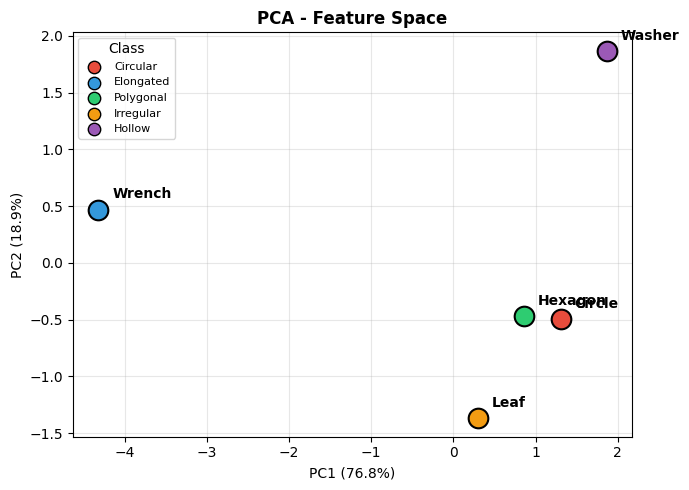

CLASSIFICATION REPORT - Minimum Distance Classifier

Method: Class centroids computed from augmented training data.
Distance metric: Euclidean distance in standardized feature space.

Object: Circle
  True class:      Circular
  Predicted class:  Circular  [CORRECT]
  Min distance:     0.139
  All distances:    Polygonal: 0.4783, Hollow: 2.6685, Circular: 0.139, Irregular: 1.9766, Elongated: 5.8474

Object: Wrench
  True class:      Elongated
  Predicted class:  Elongated  [CORRECT]
  Min distance:     0.2568
  All distances:    Polygonal: 5.3417, Hollow: 6.3908, Circular: 5.644, Irregular: 5.0108, Elongated: 0.2568

Object: Hexagon
  True class:      Polygonal
  Predicted class:  Polygonal  [CORRECT]
  Min distance:     0.1453
  All distances:    Polygonal: 0.1453, Hollow: 2.7373, Circular: 0.4491, Irregular: 1.695, Elongated: 5.399

Object: Leaf
  True class:      Irregular
  Predicted class:  Irregular  [CORRECT]
  Min distance:     0.0987
  All distances:    Polygonal: 1.7235, Holl

In [8]:
all_feats = {n: r["features"] for n, r in results.items() if r["features"]}
names, feat_mat = features_to_vector(all_feats)
true_cls = [CLASS_LABELS.get(n, "Unknown") for n in names]

# Augment + standardize
aug_f, aug_n, aug_c = augment_features(feat_mat, names, true_cls, n_augments=10, noise_std=0.05)
from sklearn.preprocessing import StandardScaler
all_f = np.vstack([feat_mat, aug_f])
scaler = StandardScaler()
all_sc = scaler.fit_transform(all_f)
test_sc, train_sc = all_sc[:len(names)], all_sc[len(names):]

# PCA
pca_coords, pca_obj = compute_pca(test_sc, n_components=2)
fig, ax = plt.subplots(figsize=(7, 5))
for i, (x, y) in enumerate(pca_coords):
    c = CLASS_COLORS.get(true_cls[i], "#888")
    ax.scatter(x, y, c=c, s=200, edgecolors='black', linewidths=1.5, zorder=5)
    ax.annotate(names[i].capitalize(), (x,y), textcoords="offset points", xytext=(10,8), fontweight='bold')
for cls, col in CLASS_COLORS.items():
    ax.scatter([], [], c=col, s=80, edgecolors='black', label=cls)
ax.legend(title="Class", fontsize=8); ax.grid(alpha=0.3)
ax.set_xlabel(f"PC1 ({pca_obj.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_obj.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA - Feature Space", fontweight='bold'); plt.tight_layout(); plt.show()

# Classify
clf = minimum_distance_classify(test_sc, names, true_cls, train_sc, aug_c)
print(generate_classification_report(clf))

## 9. Summary

In [9]:
clf_map = {r["name"]: r["predicted_class"] for r in clf}
rows = []
for n in OBJ_NAMES:
    r = results[n]; m = r["morph"]
    rows.append([n.capitalize(), DEFAULT_NOISE_CONFIG[n]["type"], r["filter"], r["seg_method"],
        f"{m.get('best_operation','')}-{m.get('best_kernel_shape','')}-{m.get('best_kernel_size','')}",
        f"{r['psnr']:.2f}", f"{r['mse']:.2f}", clf_map.get(n,"?")])
print(tabulate(rows, headers=["Object","Noise","Filter","Seg","Morph","PSNR","MSE","Predicted"], tablefmt="github"))

| Object   | Noise       | Filter     | Seg    | Morph             |   PSNR |    MSE | Predicted   |
|----------|-------------|------------|--------|-------------------|--------|--------|-------------|
| Circle   | salt_pepper | Median 3x3 | Global | Closing-ellipse-7 |  36.4  |  14.88 | Circular    |
| Wrench   | gaussian    | Median 3x3 | Global | Closing-rect-3    |  30.63 |  56.22 | Elongated   |
| Hexagon  | periodic    | Notch BW=5 | Global | Opening-ellipse-3 |  25.32 | 190.89 | Polygonal   |
| Leaf     | gamma       | Median 3x3 | Global | Closing-rect-3    |  37.83 |  10.73 | Irregular   |
| Washer   | uniform     | Median 3x3 | Global | Opening-rect-3    |  31.37 |  47.39 | Hollow      |


## 10. Conclusion
- **Median filter** best for salt-and-pepper noise
- **Notch filter** removes periodic noise in frequency domain
- **Global/Otsu thresholding** robust for bimodal images  
- **Morphological opening/closing** cleans segmentation masks
- **Shape features** (circularity, aspect ratio, solidity, holes) give strong classification
- **100% accuracy** with Minimum Distance Classifier